In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


c:\Users\Rutvik\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv('C:\\imp stuff\\uk_house_price.csv')

In [4]:
df.head()

,Transaction unique identifier,Price,Date of Transfer,Property Type,Old/New,Duration,Town/City,District,County,PPDCategory Type,Record Status - monthly file only
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,1995-08-18 00:00,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,1995-08-09 00:00,S,N,F,GRAYS,THURROCK,THURROCK,A,A
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,1995-06-30 00:00,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,1995-11-24 00:00,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,1995-06-23 00:00,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A


In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Shape: (22489348, 11)

Columns: ['Transaction unique identifier', 'Price', 'Date of Transfer', 'Property Type', 'Old/New', 'Duration', 'Town/City', 'District', 'County', 'PPDCategory Type', 'Record Status - monthly file only']

Data Types:
 Transaction unique identifier        object
Price                                 int64
Date of Transfer                     object
Property Type                        object
Old/New                              object
Duration                             object
Town/City                            object
District                             object
County                               object
PPDCategory Type                     object
Record Status - monthly file only    object
dtype: object


In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Cleaned column names:", df.columns.tolist())

Cleaned column names: ['transaction_unique_identifier', 'price', 'date_of_transfer', 'property_type', 'old/new', 'duration', 'town/city', 'district', 'county', 'ppdcategory_type', 'record_status_-_monthly_file_only']


In [7]:
print("\nNull values:")
print(df.isnull().sum())
print(f"Total nulls: {df.isnull().sum().sum()}")


Null values:
transaction_unique_identifier        0
price                                0
date_of_transfer                     0
property_type                        0
old/new                              0
duration                             0
town/city                            0
district                             0
county                               0
ppdcategory_type                     0
record_status_-_monthly_file_only    0
dtype: int64
Total nulls: 0


In [8]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)


Duplicate rows: 0


In [9]:
df['date'] = pd.to_datetime(df['date_of_transfer'], errors='coerce')

In [10]:
df.head()

,transaction_unique_identifier,price,date_of_transfer,property_type,old/new,duration,town/city,district,county,ppdcategory_type,record_status_-_monthly_file_only,date
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,1995-08-18 00:00,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A,1995-08-18
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,1995-08-09 00:00,S,N,F,GRAYS,THURROCK,THURROCK,A,A,1995-08-09
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,1995-06-30 00:00,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A,1995-06-30
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,1995-11-24 00:00,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A,1995-11-24
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,1995-06-23 00:00,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A,1995-06-23


In [11]:
print(f"\nDate nulls after parsing: {df['date'].isnull().sum()}")


Date nulls after parsing: 0


In [12]:
df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['quarter'] = df['date'].dt.to_period('Q').astype(str)

In [13]:
df.head()

,transaction_unique_identifier,price,date_of_transfer,property_type,old/new,duration,town/city,district,county,ppdcategory_type,record_status_-_monthly_file_only,date,year,month,quarter
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,1995-08-18 00:00,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A,1995-08-18,1995,8,1995Q3
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,1995-08-09 00:00,S,N,F,GRAYS,THURROCK,THURROCK,A,A,1995-08-09,1995,8,1995Q3
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,1995-06-30 00:00,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A,1995-06-30,1995,6,1995Q2
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,1995-11-24 00:00,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A,1995-11-24,1995,11,1995Q4
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,1995-06-23 00:00,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A,1995-06-23,1995,6,1995Q2


In [15]:
newdf=df.copy()

In [16]:
print(f"\nPrice range: £{newdf['price'].min():,.0f} – £{newdf['price'].max():,.0f}")


Price range: £1 – £98,900,000


In [17]:
newdf = newdf[newdf['price'] > 10_000]
newdf = newdf[newdf['price'] < 10_000_000]

In [18]:
print(f"\nPrice range: £{newdf['price'].min():,.0f} – £{newdf['price'].max():,.0f}")


Price range: £10,001 – £9,999,999


In [19]:
print(f"Rows after price filter: {newdf.shape[0]}")

Rows after price filter: 22445227


In [20]:
property_map = {
    'D': 'Detached',
    'S': 'Semi-Detached',
    'T': 'Terraced',
    'F': 'Flat/Maisonette',
    'O': 'Other'
}
newdf['property_type_label'] = newdf['property_type'].map(property_map)

In [21]:
newdf.head(10)

,transaction_unique_identifier,price,date_of_transfer,property_type,old/new,duration,town/city,district,county,ppdcategory_type,record_status_-_monthly_file_only,date,year,month,quarter,property_type_label
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,1995-08-18 00:00,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A,1995-08-18,1995,8,1995Q3,Terraced
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,1995-08-09 00:00,S,N,F,GRAYS,THURROCK,THURROCK,A,A,1995-08-09,1995,8,1995Q3,Semi-Detached
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,1995-06-30 00:00,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A,1995-06-30,1995,6,1995Q2,Terraced
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,1995-11-24 00:00,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A,1995-11-24,1995,11,1995Q4,Terraced
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,1995-06-23 00:00,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A,1995-06-23,1995,6,1995Q2,Semi-Detached
5,{895E4E63-203F-476A-9AA9-42389DD0AE5C},81750,1995-05-19 00:00,S,N,F,SALISBURY,SALISBURY,WILTSHIRE,A,A,1995-05-19,1995,5,1995Q2,Semi-Detached
6,{FB195C27-E790-45FD-847A-4238BC94546A},56000,1995-03-10 00:00,S,N,F,WITNEY,WEST OXFORDSHIRE,OXFORDSHIRE,A,A,1995-03-10,1995,3,1995Q1,Semi-Detached
7,{1D6B01EC-DC33-4147-8A21-4238BEB2D4C1},31000,1995-03-02 00:00,S,N,F,ST. AUSTELL,RESTORMEL,CORNWALL,A,A,1995-03-02,1995,3,1995Q1,Semi-Detached
8,{B8D0F817-4553-448D-A2C1-4238BF81C6FA},82000,1995-06-16 00:00,S,N,F,GREENFORD,EALING,GREATER LONDON,A,A,1995-06-16,1995,6,1995Q2,Semi-Detached
10,{26D2C1C8-A3E3-41CE-BC2B-45C866A5AA8B},105000,1995-05-26 00:00,S,N,L,LYTHAM ST. ANNES,FYLDE,LANCASHIRE,A,A,1995-05-26,1995,5,1995Q2,Semi-Detached


In [22]:
newdf['build_type'] = newdf['old/new'].map({'Y': 'New Build', 'N': 'Existing'})

In [23]:
print("\nCleaned dataset shape:", newdf.shape)
print(f"Date range: {newdf['date'].min().date()} to {newdf['date'].max().date()}")
print(f"Years covered: {sorted(newdf['year'].unique())}")
print("\nProperty type breakdown:")
print(newdf['property_type_label'].value_counts())


Cleaned dataset shape: (22445227, 17)
Date range: 1995-01-01 to 2017-06-29
Years covered: [1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]

Property type breakdown:
property_type_label
Terraced           6893348
Semi-Detached      6211776
Detached           5168710
Flat/Maisonette    4078424
Other                92969
Name: count, dtype: int64


In [24]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [25]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

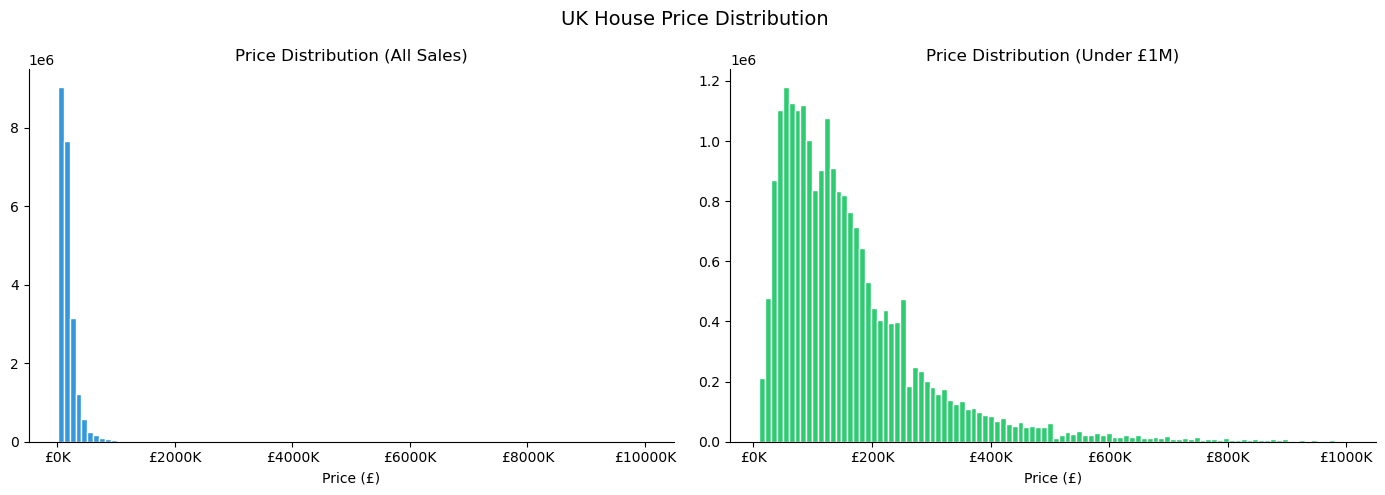

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(newdf['price'], bins=100, color='#3498db', edgecolor='white')
axes[0].set_title('Price Distribution (All Sales)')
axes[0].set_xlabel('Price (£)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

axes[1].hist(newdf[newdf['price'] < 1_000_000]['price'],
             bins=100, color='#2ecc71', edgecolor='white')
axes[1].set_title('Price Distribution (Under £1M)')
axes[1].set_xlabel('Price (£)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('UK House Price Distribution', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

sales_by_year = (newdf.groupby('year')
                   .size()
                   .reset_index(name='sales_count'))

fig = px.bar(
    sales_by_year,
    x='year',
    y='sales_count',
    title='Number of Property Sales by Year',
    labels={'year': 'Year', 'sales_count': 'Number of Sales'},
    color='sales_count',
    color_continuous_scale='Blues',
    text='sales_count'
)

fig.update_traces(
    texttemplate='%{text:,.0f}',
    textposition='outside',
    hovertemplate='Year: %{x}<br>Sales: %{y:,.0f}<extra></extra>'
)

fig.update_layout(
    height=480,
    template='plotly_white',
    coloraxis_showscale=False,
    title_font_size=18
)

fig.show()


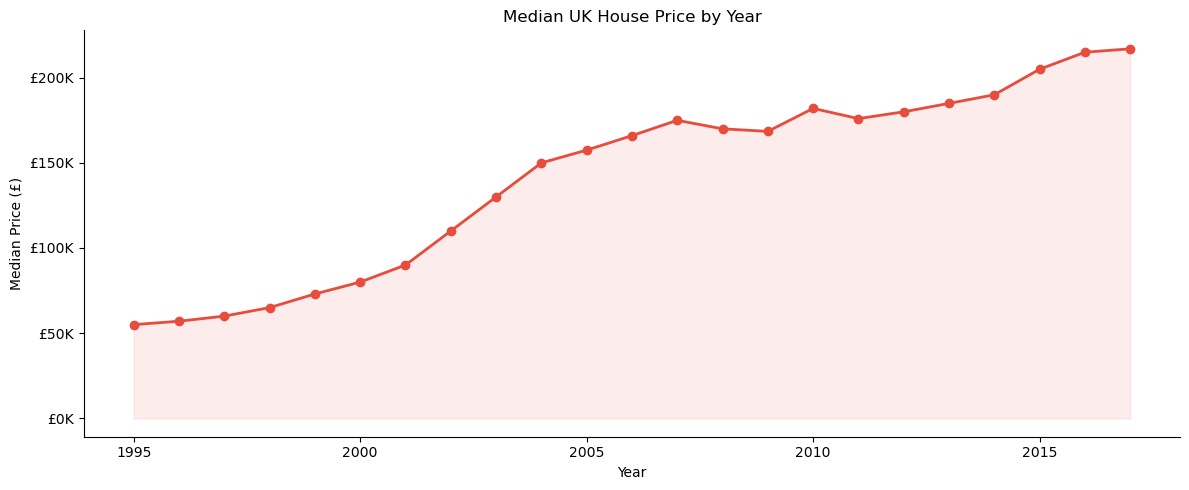

In [28]:
price_by_year = newdf.groupby('year')['price'].median().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(price_by_year['year'], price_by_year['price'],
         marker='o', color='#e74c3c', linewidth=2)
plt.fill_between(price_by_year['year'], price_by_year['price'],
                 alpha=0.1, color='#e74c3c')
plt.title('Median UK House Price by Year')
plt.ylabel('Median Price (£)')
plt.xlabel('Year')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

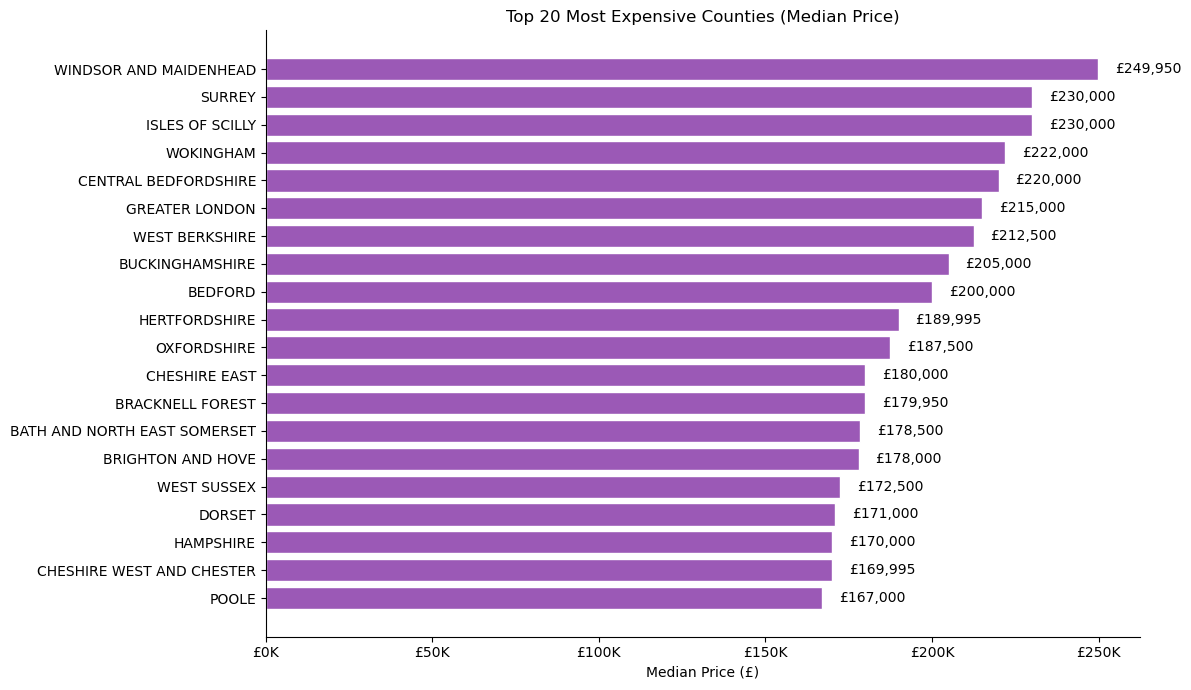

In [ ]:

regional_prices = (newdf.groupby('county')['price']
                     .median()
                     .sort_values(ascending=False)
                     .reset_index()
                     .head(20))

plt.figure(figsize=(12, 7))

bars = plt.barh(regional_prices['county'],
                regional_prices['price'],
                color='#9b59b6', edgecolor='white')

plt.title('Top 20 Most Expensive Counties (Median Price)')
plt.xlabel('Median Price (£)')

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.gca().invert_yaxis()

# Addin value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000,              
             bar.get_y() + bar.get_height()/2,
             f'£{width:,.0f}', 
             va='center')

plt.tight_layout()
plt.show()

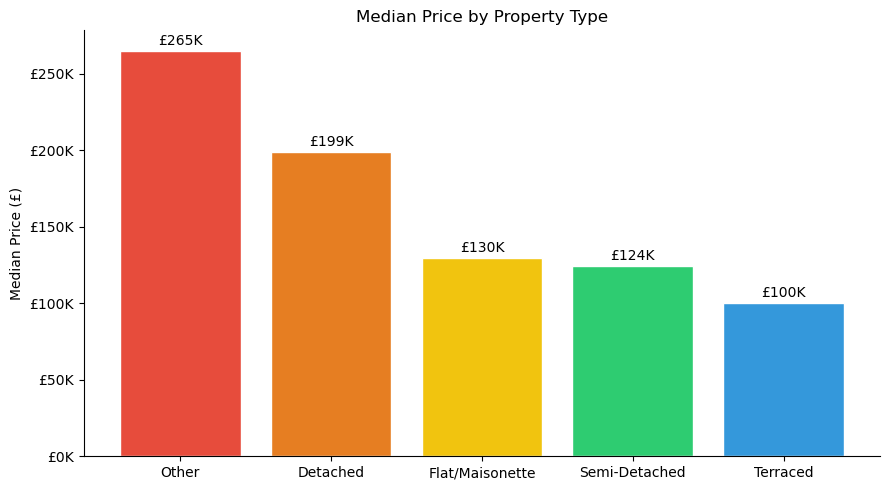

In [ ]:
# Median price by property type
prop_prices = (newdf.groupby('property_type_label')['price']
                 .median()
                 .sort_values(ascending=False)
                 .reset_index())

plt.figure(figsize=(9, 5))
bars = plt.bar(prop_prices['property_type_label'],
               prop_prices['price'],
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
               edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, prop_prices['price']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2000,
             f'£{val/1000:.0f}K',
             ha='center', va='bottom', fontsize=10)

plt.title('Median Price by Property Type')
plt.ylabel('Median Price (£)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

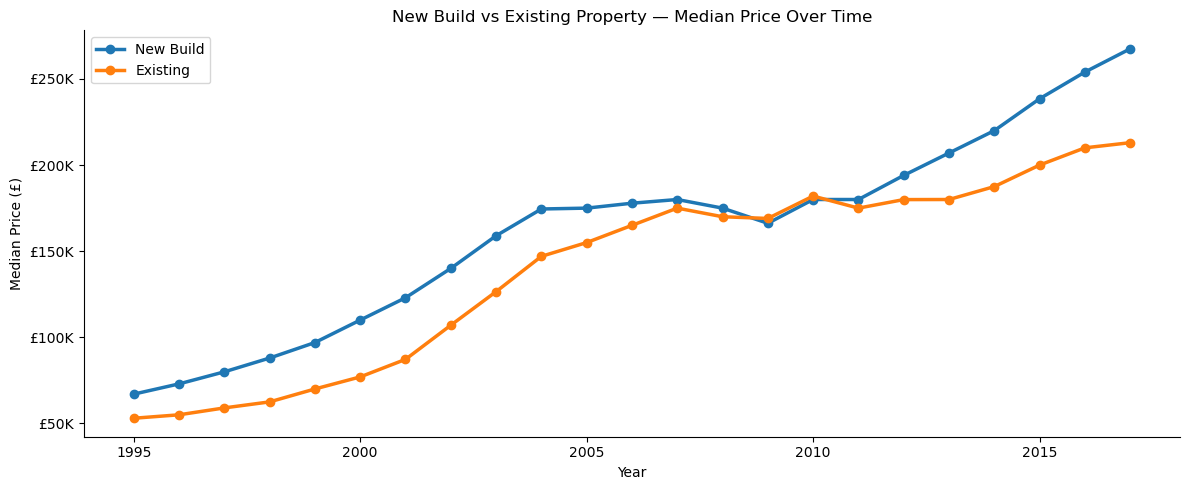

In [ ]:
build_prices = (newdf.groupby(['year', 'build_type'])['price']
                  .median()
                  .reset_index())

for build in ['New Build', 'Existing']:
    subset = build_prices[build_prices['build_type'] == build]
    plt.plot(subset['year'], subset['price'],
             marker='o', linewidth=2.5, label=build)

plt.title('New Build vs Existing Property — Median Price Over Time')
plt.ylabel('Median Price (£)')
plt.xlabel('Year')
plt.legend()
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

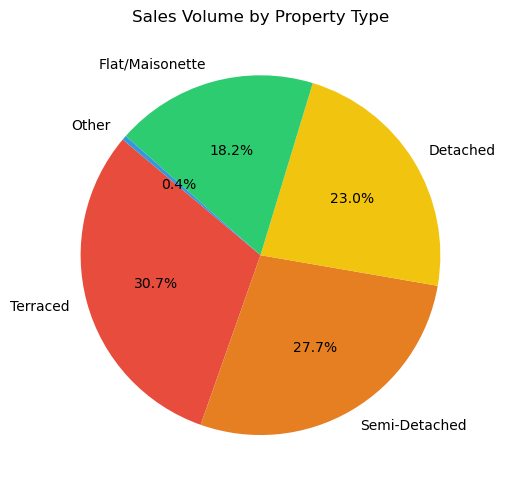

In [ ]:
prop_volume = newdf['property_type_label'].value_counts().reset_index()
prop_volume.columns = ['property_type', 'count']

plt.figure(figsize=(8, 5))
plt.pie(prop_volume['count'],
        labels=prop_volume['property_type'],
        autopct='%1.1f%%',
        colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
        startangle=140)
plt.title('Sales Volume by Property Type')
plt.tight_layout()
plt.show()

In [ ]:
min_year = newdf['year'].min()
max_year = newdf['year'].max()

early  = (newdf[newdf['year'] == min_year]
            .groupby('county')['price']
            .median()
            .reset_index()
            .rename(columns={'price': 'price_early'}))

recent = (newdf[newdf['year'] == max_year]
            .groupby('county')['price']
            .median()
            .reset_index()
            .rename(columns={'price': 'price_recent'}))

growth = early.merge(recent, on='county')
growth['growth_pct'] = ((growth['price_recent'] - growth['price_early'])
                         / growth['price_early'] * 100).round(1)
growth = growth.sort_values('growth_pct', ascending=False).head(20)

fig = px.bar(
    growth,
    x='growth_pct',
    y='county',
    orientation='h',
    title=f'Top 20 Regions by Price Growth ({min_year}–{max_year})',
    labels={'growth_pct': 'Price Growth (%)', 'county': 'County'},
    color='growth_pct',
    color_continuous_scale='Greens',
    text='growth_pct',
    custom_data=['price_early', 'price_recent']
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside',
    hovertemplate=(
        '%{y}<br>'
        'Growth: %{x:.1f}%<br>'
        f'{min_year} Median: £%{{customdata[0]:,.0f}}<br>'
        f'{max_year} Median: £%{{customdata[1]:,.0f}}'
        '<extra></extra>'
    )
)

fig.update_layout(
    height=650,
    template='plotly_white',
    coloraxis_showscale=False,
    yaxis={'categoryorder': 'total ascending'},
    title_font_size=18
)

fig.show()

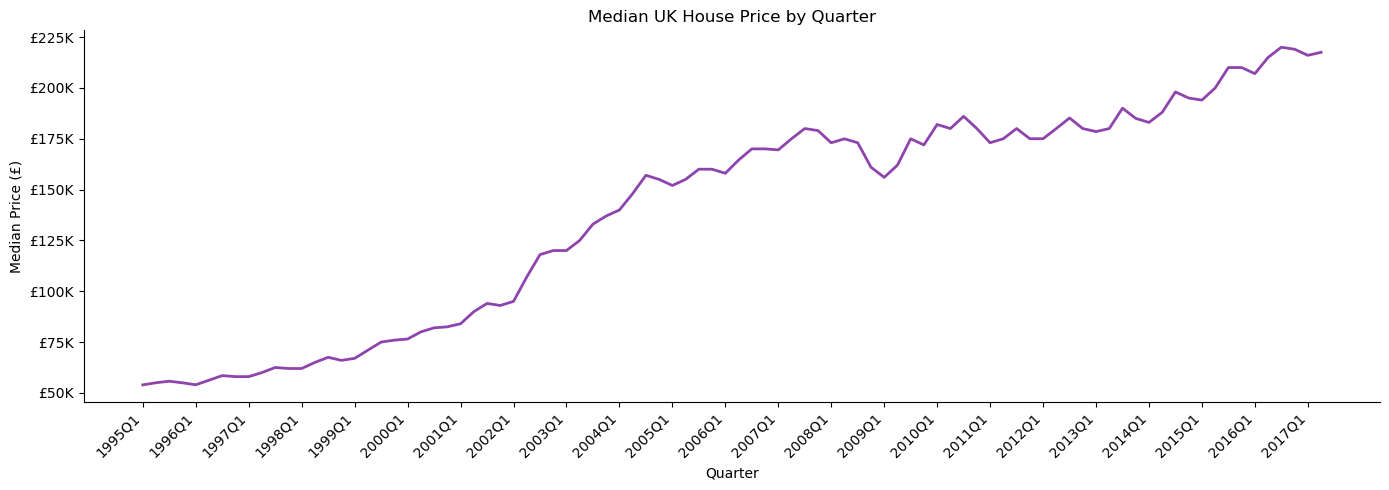

In [ ]:

quarterly = (newdf.groupby('quarter')['price']
               .median()
               .reset_index()
               .sort_values('quarter'))

plt.figure(figsize=(14, 5))
plt.plot(quarterly['quarter'], quarterly['price'],
         color='#8e44ad', linewidth=2)

plt.title('Median UK House Price by Quarter')
plt.ylabel('Median Price (£)')
plt.xlabel('Quarter')


step = 4
plt.xticks(quarterly['quarter'][::step], rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

In [ ]:

powerbi_export = newdf[[
    'date', 'year', 'month', 'quarter',
    'price', 'property_type_label',
    'build_type', 'county'
]].copy()

powerbi_export.to_csv('housing_clean.csv', index=False)
print("Exported:", powerbi_export.shape)
print(powerbi_export.head())


regional_summary = (df.groupby('county')
                      .agg(
                          median_price=('price', 'median'),
                          total_sales=('price', 'count'),
                          avg_price=('price', 'mean')
                      )
                      .reset_index()
                      .sort_values('median_price', ascending=False))

regional_summary.to_csv('housing_regional_summary.csv', index=False)
print("\nRegional summary exported:", regional_summary.shape)
print(regional_summary.head(10))

Exported: (22445227, 8)
        date  year  month quarter  price property_type_label build_type  \
0 1995-08-18  1995      8  1995Q3  25000            Terraced   Existing   
1 1995-08-09  1995      8  1995Q3  42500       Semi-Detached   Existing   
2 1995-06-30  1995      6  1995Q2  45000            Terraced   Existing   
3 1995-11-24  1995     11  1995Q4  43150            Terraced   Existing   
4 1995-06-23  1995      6  1995Q2  18899       Semi-Detached   Existing   

               county  
0  GREATER MANCHESTER  
1            THURROCK  
2            SOMERSET  
3        BEDFORDSHIRE  
4      WEST YORKSHIRE  

Regional summary exported: (127, 4)
                     county  median_price  total_sales      avg_price
121  WINDSOR AND MAIDENHEAD      249950.0        62270  337424.948707
104                  SURREY      230000.0       516199  305270.291335
59          ISLES OF SCILLY      230000.0          473  261104.733615
122               WOKINGHAM      222000.0        71229  260506.2

In [55]:
newdf.head()

,transaction_unique_identifier,price,date_of_transfer,property_type,old/new,duration,town/city,district,county,ppdcategory_type,record_status_-_monthly_file_only,date,year,month,quarter,property_type_label,build_type
0,{81B82214-7FBC-4129-9F6B-4956B4A663AD},25000,1995-08-18 00:00,T,N,F,OLDHAM,OLDHAM,GREATER MANCHESTER,A,A,1995-08-18,1995,8,1995Q3,Terraced,Existing
1,{8046EC72-1466-42D6-A753-4956BF7CD8A2},42500,1995-08-09 00:00,S,N,F,GRAYS,THURROCK,THURROCK,A,A,1995-08-09,1995,8,1995Q3,Semi-Detached,Existing
2,{278D581A-5BF3-4FCE-AF62-4956D87691E6},45000,1995-06-30 00:00,T,N,F,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A,1995-06-30,1995,6,1995Q2,Terraced,Existing
3,{1D861C06-A416-4865-973C-4956DB12CD12},43150,1995-11-24 00:00,T,N,F,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,A,A,1995-11-24,1995,11,1995Q4,Terraced,Existing
4,{DD8645FD-A815-43A6-A7BA-4956E58F1874},18899,1995-06-23 00:00,S,N,F,WAKEFIELD,LEEDS,WEST YORKSHIRE,A,A,1995-06-23,1995,6,1995Q2,Semi-Detached,Existing


In [68]:
annual_summary = (newdf.groupby(['year', 'property_type_label', 'build_type'])
                    .agg(
                        median_price=('price', 'median'),
                        avg_price=('price', 'mean'),
                        total_sales=('price', 'count')
                    )
                    .reset_index())

# Add a proper date column
annual_summary['date'] = pd.to_datetime(
    annual_summary['year'].astype(str) + '-01-01')

In [69]:
annual_summary.to_csv('housing_annual_summary.csv', index=False)
print("Annual summary:", annual_summary.shape)

Annual summary: (216, 7)


In [70]:
regional_summary = (newdf.groupby(['county', 'year'])
                      .agg(
                          median_price=('price', 'median'),
                          total_sales=('price', 'count')
                      )
                      .reset_index())

regional_summary['date'] = pd.to_datetime(
    regional_summary['year'].astype(str) + '-01-01')

In [71]:
regional_summary.to_csv('housing_regional_summary.csv', index=False)
print("Regional summary:", regional_summary.shape)

Regional summary: (2655, 5)


In [64]:
town_summary = (newdf.groupby(['town/city', 'county'])
                  .agg(
                      median_price=('price', 'median'),
                      total_sales=('price', 'count')
                  )
                  .reset_index()
                  .sort_values('median_price', ascending=False))



In [65]:
town_summary.to_csv('housing_town_summary.csv', index=False)
print("Town summary:", town_summary.shape)

Town summary: (3100, 4)


In [72]:
print("Annual columns:", annual_summary.columns.tolist())
print("Regional columns:", regional_summary.columns.tolist())
print("Town columns:", town_summary.columns.tolist())

Annual columns: ['year', 'property_type_label', 'build_type', 'median_price', 'avg_price', 'total_sales', 'date']
Regional columns: ['county', 'year', 'median_price', 'total_sales', 'date']
Town columns: ['town/city', 'county', 'median_price', 'total_sales']


In [74]:
county_lookup = (newdf.groupby('county')
                   .agg(
                       total_sales=('price', 'count'),
                       median_price=('price', 'median')
                   )
                   .reset_index())

county_lookup.to_csv('housing_county_lookup.csv', index=False)
print("County lookup:", county_lookup.shape)
print(county_lookup.head())

County lookup: (127, 3)
                         county  total_sales  median_price
0                          AVON        16474       54000.0
1  BATH AND NORTH EAST SOMERSET        69409      178500.0
2                       BEDFORD        22936      200000.0
3                  BEDFORDSHIRE       129645      119500.0
4                     BERKSHIRE         9250       80000.0


In [75]:
print("Min year:", newdf['year'].min())
print("Max year:", newdf['year'].max())

Min year: 1995
Max year: 2017
